# Phase 4: Correlation Analysis

Investigates whether post-game press conference sentiment correlates with NBA playoff series outcomes.

**Four analyses:**
1. Pearson correlation: game-day aggregate sentiment vs point differential
2. Pearson correlation: game-day sentiment vs NEXT game point differential
3. Series trajectory: average sentiment by game number (1-7)
4. Elimination game sentiment: is aggregate sentiment more negative in series-ending games?

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

import sys
sys.path.insert(0, str(Path("..").resolve()))

from src.analysis.correlations import run_all

PROCESSED_DIR = Path("..") / "data" / "processed"

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

## Load and join data

In [2]:
results = run_all(save=True)

joined   = results["joined"]
game_agg = results["game_agg"]
pearson  = results["pearson"]
traj     = results["trajectory"]
elim     = results["elimination"]
pos      = results["series_pos"]

print(f"\nGame-level aggregates: {len(game_agg)} rows")
game_agg.head()

Loading sentiment scores...
  23,166 scored turns

Joining with game data...


Joined: 10,881 turns matched to games
Unmatched (off-day or parse failure): 12,285

Building game-level aggregates...
  141 games with press conference data
  Saved sentiment_game_joined.csv and game_sentiment_agg.csv

--- Analysis 1: Pearson correlations ---
  sentiment vs point_diff (same game): r=-0.088, p=0.2974, n=141
  sentiment vs next-game point_diff: r=-0.109, p=0.1962, n=141
  pct_positive vs point_diff: r=-0.066, p=0.434, n=141
  pct_negative vs point_diff: r=0.053, p=0.5332, n=141

--- Analysis 2: Series trajectory ---
 game_num  mean_sentiment  std_sentiment  n_turns
        1        0.290191       0.705945     1960
        2        0.295539       0.732746     1817
        3        0.248973       0.737470     1803
        4        0.305927       0.716103     1864
        5        0.383839       0.717394     1712
        6        0.472253       0.713339     1289
        7        0.428618       0.745320      436

--- Analysis 3: Elimination game sentiment ---
  Elimination g

,game_id,date,event_name,series_id,game_num,home_team,away_team,home_win,point_diff,is_elimination_game,next_point_diff,home_series_wins,away_series_wins,mean_sentiment,pct_positive,pct_negative,n_turns
0,41200301,2013-05-22,NBA ECF: PACERS v HEAT,"('IND', 'MIA')_2012",1,MIA,IND,1,1.0,0,-4.0,1,0,0.126137,0.291667,0.166667,48
1,41200302,2013-05-24,NBA ECF: PACERS v HEAT,"('IND', 'MIA')_2012",2,MIA,IND,0,-4.0,0,-18.0,1,1,0.221557,0.428571,0.214286,56
2,41200303,2013-05-26,NBA ECF: PACERS v HEAT,"('IND', 'MIA')_2012",3,IND,MIA,0,-18.0,0,7.0,1,2,0.205530,0.393939,0.212121,33
3,41200304,2013-05-28,NBA ECF: PACERS v HEAT,"('IND', 'MIA')_2012",4,IND,MIA,1,7.0,0,11.0,2,2,0.121129,0.326923,0.192308,52
4,41200305,2013-05-30,NBA ECF: PACERS v HEAT,"('IND', 'MIA')_2012",5,MIA,IND,1,11.0,0,14.0,3,2,0.284116,0.491803,0.213115,61


## Analysis 1: Pearson Correlations

In [3]:
print("Pearson correlation results:\n")
rows = []
for label, res in pearson.items():
    sig = "*" if res["p"] < 0.05 else ""
    print(f"  {label}")
    print(f"    r = {res['r']:+.3f},  p = {res['p']:.4f}{sig},  n = {res['n']}")
    rows.append({"comparison": label, "r": res["r"], "p": res["p"], "n": res["n"], "significant": res["p"] < 0.05})

pearson_df = pd.DataFrame(rows)
pearson_df

Pearson correlation results:

  sentiment vs point_diff (same game)
    r = -0.088,  p = 0.2974,  n = 141
  sentiment vs next-game point_diff
    r = -0.109,  p = 0.1962,  n = 141
  pct_positive vs point_diff
    r = -0.066,  p = 0.4340,  n = 141
  pct_negative vs point_diff
    r = +0.053,  p = 0.5332,  n = 141


,comparison,r,p,n,significant
0,sentiment vs point_diff (same game),-0.088,0.2974,141,False
1,sentiment vs next-game point_diff,-0.109,0.1962,141,False
2,pct_positive vs point_diff,-0.066,0.4340,141,False
3,pct_negative vs point_diff,0.053,0.5332,141,False


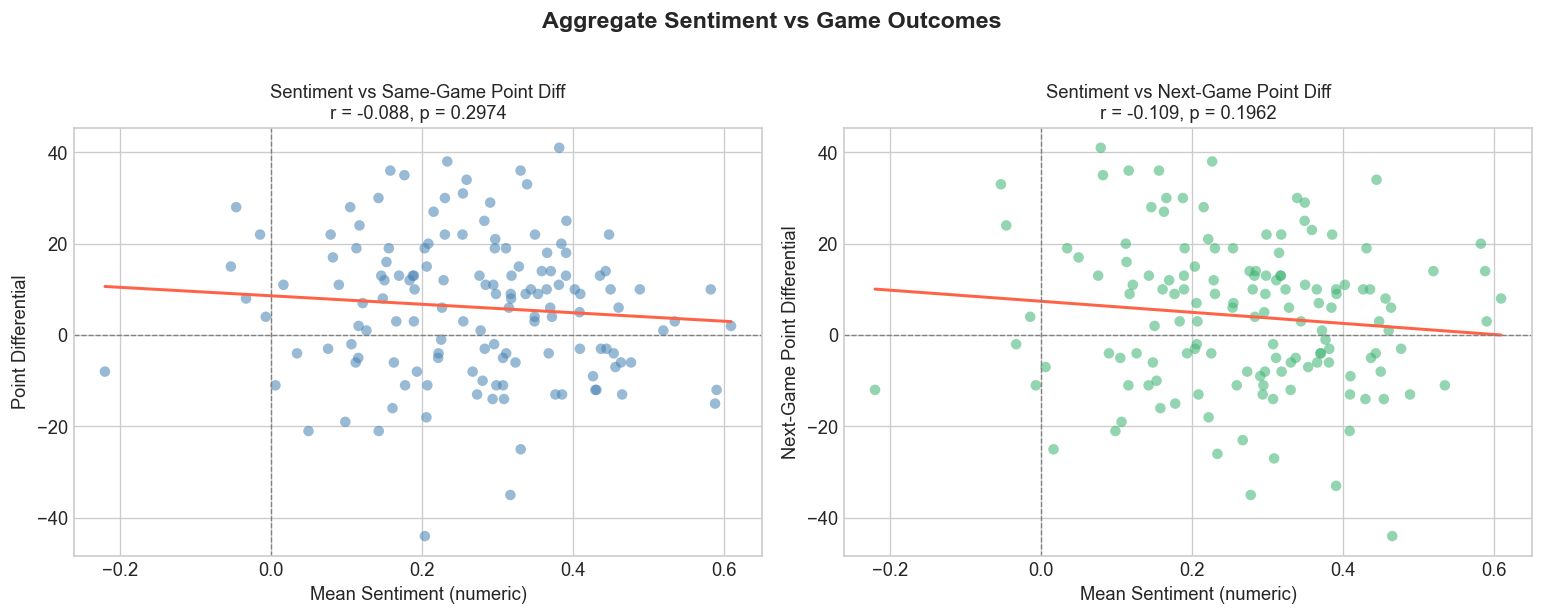

Saved 04_pearson_scatter.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Aggregate Sentiment vs Game Outcomes", fontsize=14, fontweight="bold", y=1.02)

# Scatter 1: sentiment vs same-game point diff
ax = axes[0]
mask = game_agg[["mean_sentiment", "point_diff"]].notna().all(axis=1)
x, y = game_agg.loc[mask, "mean_sentiment"], game_agg.loc[mask, "point_diff"]
ax.scatter(x, y, alpha=0.55, s=40, color="steelblue", edgecolors="none")
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m * xline + b, color="tomato", linewidth=1.8)
r, p = pearson["sentiment vs point_diff (same game)"]["r"], pearson["sentiment vs point_diff (same game)"]["p"]
ax.set_title(f"Sentiment vs Same-Game Point Diff\nr = {r:+.3f}, p = {p:.4f}", fontsize=11)
ax.set_xlabel("Mean Sentiment (numeric)")
ax.set_ylabel("Point Differential")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")

# Scatter 2: sentiment vs next-game point diff
ax = axes[1]
mask2 = game_agg[["mean_sentiment", "next_point_diff"]].notna().all(axis=1)
x2, y2 = game_agg.loc[mask2, "mean_sentiment"], game_agg.loc[mask2, "next_point_diff"]
ax.scatter(x2, y2, alpha=0.55, s=40, color="mediumseagreen", edgecolors="none")
m2, b2 = np.polyfit(x2, y2, 1)
xline2 = np.linspace(x2.min(), x2.max(), 100)
ax.plot(xline2, m2 * xline2 + b2, color="tomato", linewidth=1.8)
r2, p2 = pearson["sentiment vs next-game point_diff"]["r"], pearson["sentiment vs next-game point_diff"]["p"]
ax.set_title(f"Sentiment vs Next-Game Point Diff\nr = {r2:+.3f}, p = {p2:.4f}", fontsize=11)
ax.set_xlabel("Mean Sentiment (numeric)")
ax.set_ylabel("Next-Game Point Differential")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.savefig("04_pearson_scatter.png", bbox_inches="tight")
plt.show()
print("Saved 04_pearson_scatter.png")

## Analysis 2: Series Trajectory

In [5]:
print("Mean sentiment by game number within series:\n")
print(traj.to_string(index=False))

Mean sentiment by game number within series:

 game_num  mean_sentiment  std_sentiment  n_turns
        1        0.290191       0.705945     1960
        2        0.295539       0.732746     1817
        3        0.248973       0.737470     1803
        4        0.305927       0.716103     1864
        5        0.383839       0.717394     1712
        6        0.472253       0.713339     1289
        7        0.428618       0.745320      436


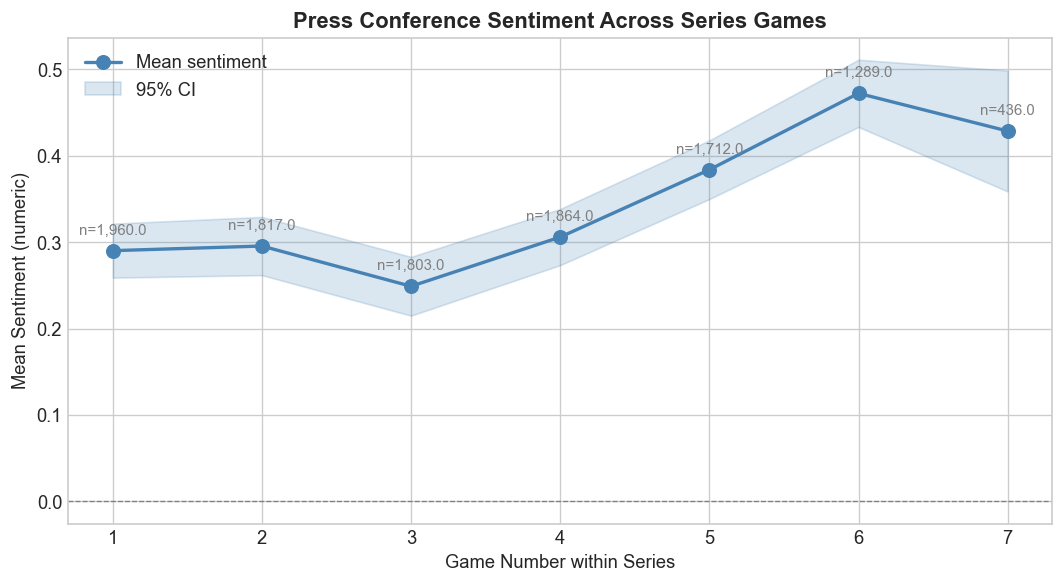

Saved 04_series_trajectory.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(traj["game_num"], traj["mean_sentiment"], marker="o", linewidth=2,
        color="steelblue", markersize=8, label="Mean sentiment")

# 95% CI bands
sem = traj["std_sentiment"] / np.sqrt(traj["n_turns"])
ax.fill_between(
    traj["game_num"],
    traj["mean_sentiment"] - 1.96 * sem,
    traj["mean_sentiment"] + 1.96 * sem,
    alpha=0.20, color="steelblue", label="95% CI"
)

# Annotate sample counts
for _, row in traj.iterrows():
    ax.annotate(f"n={row['n_turns']:,}",
                (row["game_num"], row["mean_sentiment"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9, color="gray")

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xticks(traj["game_num"])
ax.set_xlabel("Game Number within Series")
ax.set_ylabel("Mean Sentiment (numeric)")
ax.set_title("Press Conference Sentiment Across Series Games", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("04_series_trajectory.png", bbox_inches="tight")
plt.show()
print("Saved 04_series_trajectory.png")

## Analysis 3: Elimination Game Sentiment

In [7]:
print("Elimination game analysis:")
print(f"  Elimination games (n={elim['n_elim']}):     mean sentiment = {elim['elim_mean']}")
print(f"  Non-elimination games (n={elim['n_normal']}): mean sentiment = {elim['normal_mean']}")
print(f"  t-test: t = {elim['t_stat']}, p = {elim['p_value']}")
print(f"  Logistic regression coefficient: {elim['logit_coef']}")
print()
print("Classification report (predicting is_elimination_game from sentiment):")
print(elim["classification_report"])

Elimination game analysis:
  Elimination games (n=0):     mean sentiment = nan
  Non-elimination games (n=141): mean sentiment = 0.271
  t-test: t = nan, p = nan
  Logistic regression coefficient: nan

Classification report (predicting is_elimination_game from sentiment):
No elimination games in matched transcript data.


In [8]:
elim_sent   = game_agg[game_agg["is_elimination_game"] == 1]["mean_sentiment"]
normal_sent = game_agg[game_agg["is_elimination_game"] == 0]["mean_sentiment"]

if len(elim_sent) == 0:
    print("NOTE: No elimination games in matched transcript data.")
    print("      The scraper did not capture last-game press conferences for the series in this corpus.")
    print("      Analysis 3 (elimination game chart) is skipped.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Elimination Game vs Non-Elimination Game Sentiment", fontsize=13, fontweight="bold")

    ax = axes[0]
    parts = ax.violinplot([normal_sent, elim_sent], positions=[0, 1], showmedians=True, showextrema=True)
    colors = ["steelblue", "tomato"]
    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    ax.scatter([0] * len(normal_sent), normal_sent, alpha=0.4, s=20, color="steelblue", zorder=3)
    ax.scatter([1] * len(elim_sent),   elim_sent,   alpha=0.4, s=20, color="tomato",    zorder=3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"Non-elimination\n(n={elim['n_normal']})", f"Elimination\n(n={elim['n_elim']})"])
    ax.set_ylabel("Mean Sentiment (numeric)")
    ax.set_title(f"Sentiment Distribution\nt = {elim['t_stat']}, p = {elim['p_value']}")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

    ax = axes[1]
    labels  = ["Non-elimination", "Elimination"]
    means   = [elim["normal_mean"], elim["elim_mean"]]
    sems    = [normal_sent.std() / np.sqrt(len(normal_sent)), elim_sent.std() / np.sqrt(len(elim_sent))]
    bars = ax.bar(labels, means, color=["steelblue", "tomato"], alpha=0.75, yerr=sems, capsize=5)
    ax.set_ylabel("Mean Sentiment (numeric)")
    ax.set_title("Mean Sentiment (+/- SEM)")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.005 * np.sign(mean),
                f"{mean:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

    plt.tight_layout()
    plt.savefig("04_elimination_sentiment.png", bbox_inches="tight")
    plt.show()
    print("Saved 04_elimination_sentiment.png")

NOTE: No elimination games in matched transcript data.
      The scraper did not capture last-game press conferences for the series in this corpus.
      Analysis 3 (elimination game chart) is skipped.


## Analysis 4: Sentiment by Series Position

In [9]:
print("Sentiment by game number and home-team series lead status:")
print(pos.to_string(index=False))

Sentiment by game number and home-team series lead status:
 game_num  home_leads  mean_sentiment  n_turns
        1       False        0.335305      596
        1        True        0.270479     1364
        2       False        0.207960      901
        2        True        0.381684      916
        3       False        0.194098      491
        3        True        0.269509     1312
        4       False        0.304545      953
        4        True        0.307372      911
        5       False        0.328805      316
        5        True        0.396296     1396
        6       False        0.550239      637
        6        True        0.396060      652
        7       False        0.590553       62
        7        True        0.401773      374


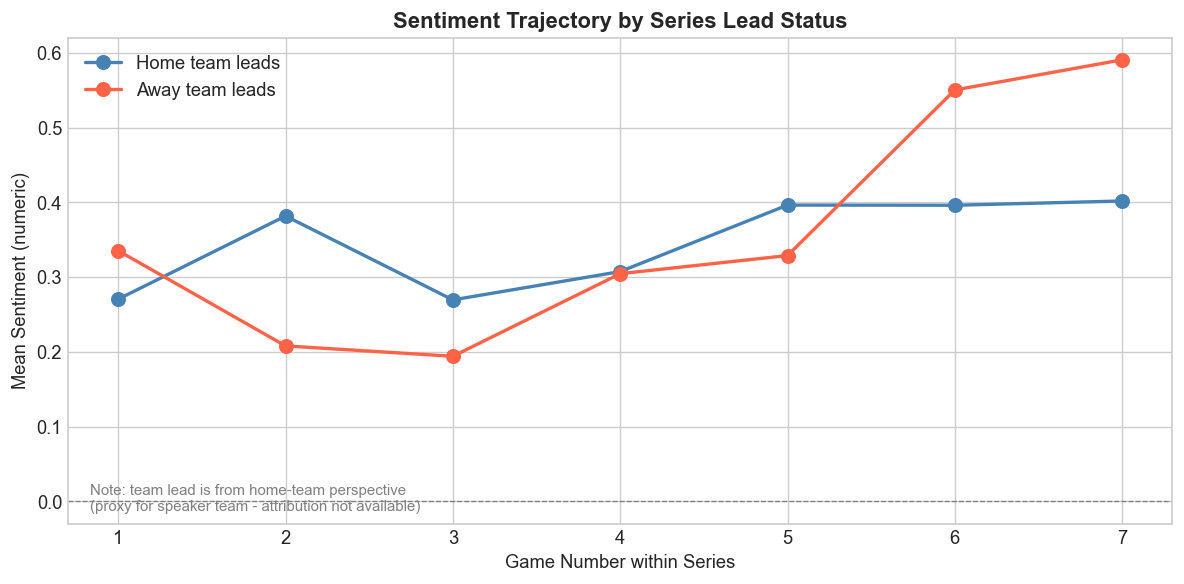

Saved 04_series_position.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for leading, label, color in [(True, "Home team leads", "steelblue"), (False, "Away team leads", "tomato")]:
    sub = pos[pos["home_leads"] == leading].sort_values("game_num")
    if len(sub) == 0:
        continue
    ax.plot(sub["game_num"], sub["mean_sentiment"], marker="o", linewidth=2,
            color=color, label=label, markersize=8)

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xticks(sorted(pos["game_num"].unique()))
ax.set_xlabel("Game Number within Series")
ax.set_ylabel("Mean Sentiment (numeric)")
ax.set_title("Sentiment Trajectory by Series Lead Status", fontweight="bold")
ax.legend()
ax.text(0.02, 0.02,
        "Note: team lead is from home-team perspective\n(proxy for speaker team - attribution not available)",
        transform=ax.transAxes, fontsize=9, color="gray", va="bottom")

plt.tight_layout()
plt.savefig("04_series_position.png", bbox_inches="tight")
plt.show()
print("Saved 04_series_position.png")

## Summary: Key Findings

In [11]:
print("=" * 65)
print("CORRELATION ANALYSIS SUMMARY")
print("=" * 65)
print()
print("1. SAME-GAME CORRELATION (sentiment -> point differential)")
r = pearson["sentiment vs point_diff (same game)"]["r"]
p = pearson["sentiment vs point_diff (same game)"]["p"]
print(f"   r = {r:+.3f}, p = {p:.4f}")
print(f"   -> {'Statistically significant' if p < 0.05 else 'Not significant'} (alpha=0.05)")
print()
print("2. PREDICTIVE CORRELATION (sentiment -> NEXT game point diff)")
r2 = pearson["sentiment vs next-game point_diff"]["r"]
p2 = pearson["sentiment vs next-game point_diff"]["p"]
print(f"   r = {r2:+.3f}, p = {p2:.4f}")
print(f"   -> {'Statistically significant' if p2 < 0.05 else 'Not significant'} (alpha=0.05)")
print()
print("3. ELIMINATION GAME EFFECT")
if elim["n_elim"] == 0:
    print("   Not available - elimination game transcripts not in corpus.")
else:
    print(f"   Elimination games:     mean = {elim['elim_mean']:+.3f}")
    print(f"   Non-elimination games: mean = {elim['normal_mean']:+.3f}")
    print(f"   t = {elim['t_stat']}, p = {elim['p_value']}")
    print(f"   -> {'Significant' if elim['p_value'] < 0.05 else 'Not significant'} difference (alpha=0.05)")
print()
print("4. TRAJECTORY")
print(f"   Game 1 sentiment: {traj[traj['game_num']==1]['mean_sentiment'].values[0]:+.3f}")
last_game = traj["game_num"].max()
print(f"   Game {last_game} sentiment: {traj[traj['game_num']==last_game]['mean_sentiment'].values[0]:+.3f}")
print("=" * 65)

CORRELATION ANALYSIS SUMMARY

1. SAME-GAME CORRELATION (sentiment -> point differential)
   r = -0.088, p = 0.2974
   -> Not significant (alpha=0.05)

2. PREDICTIVE CORRELATION (sentiment -> NEXT game point diff)
   r = -0.109, p = 0.1962
   -> Not significant (alpha=0.05)

3. ELIMINATION GAME EFFECT
   Not available - elimination game transcripts not in corpus.

4. TRAJECTORY
   Game 1 sentiment: +0.290
   Game 7 sentiment: +0.429
